In [5]:
import pandas as pd

In [6]:
df = pd.read_csv('Smartphone_Usage_And_Addiction.csv')
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

Dataset does not have many nulls/Nans. All columns have 7500 non null besides 14, addiction_level. That will need to be fixed, either average added in or rows deleted.

In [8]:
df.shape

(7500, 16)

In [9]:
df.value_counts()


transaction_id  user_id  age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  weekend_screen_time  stress_level  academic_work_impact  addiction_level  addicted_label
TXN00003        U00003   31   Other   6.06                     1.36                3.83          2.35              4.92         44                     106                8.68                 High          No                    Mild             0                 1
TXN00004        U00004   32   Other   7.83                     5.85                1.51          3.54              8.23         178                    107                9.77                 High          Yes                   Moderate         1                 1
TXN00005        U00005   25   Male    9.96                     5.92                3.42          5.27              6.21         136                    177                12.55                Low           No      

In [10]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [11]:
df['gender'].value_counts()

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

In [12]:
df.duplicated().value_counts()

False    7500
Name: count, dtype: int64

In [13]:
df['age'].value_counts().sort_index()

age
18    399
19    400
20    440
21    443
22    396
23    413
24    376
25    408
26    429
27    431
28    369
29    427
30    410
31    461
32    433
33    432
34    418
35    415
Name: count, dtype: int64

no duplicate rows. what are the 2400 "other" genders? That greatly reduces numbers when looking at gender based differences.

In [14]:
null_rows = df[df['addiction_level'].isna()]
print(null_rows)

     transaction_id user_id  age  gender  daily_screen_time_hours  \
0          TXN00001  U00001   21    Male                     3.23   
1          TXN00002  U00002   24   Other                     5.09   
8          TXN00009  U00009   21   Other                     4.38   
11         TXN00012  U00012   27   Other                     5.16   
13         TXN00014  U00014   32    Male                     4.09   
...             ...     ...  ...     ...                      ...   
7447       TXN07448  U07448   20  Female                     5.00   
7454       TXN07455  U07455   29   Other                     3.45   
7457       TXN07458  U07458   29  Female                     3.11   
7481       TXN07482  U07482   29    Male                     4.72   
7496       TXN07497  U07497   35    Male                     5.67   

      social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                   2.01          0.89              4.55         7.55   
1                   3.81 

In [15]:
df = df.dropna()


In [16]:
df.shape

(6681, 16)

In [17]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='str')

In [18]:
df.value_counts('stress_level')

stress_level
High      2271
Low       2254
Medium    2156
Name: count, dtype: int64

In [19]:
print(df.value_counts('addiction_level'))
print(df.value_counts('academic_work_impact'))
print(df.value_counts('addiction_level'))
print(df.value_counts('addicted_label'))


addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64
academic_work_impact
No     3346
Yes    3335
Name: count, dtype: int64
addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64
addicted_label
1    5308
0    1373
Name: count, dtype: int64


In [20]:
df_subset = df[['addiction_level', 'addicted_label']]
print(df_subset)

     addiction_level  addicted_label
2               Mild               0
3           Moderate               1
4             Severe               1
5             Severe               1
6             Severe               1
...              ...             ...
7494          Severe               1
7495        Moderate               1
7497          Severe               1
7498          Severe               1
7499          Severe               1

[6681 rows x 2 columns]


In [21]:
df['addicted_label'] = df['addicted_label'].replace({1:'Yes', 0:'No'})
print(df.head())


  transaction_id user_id  age gender  daily_screen_time_hours  \
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   
5       TXN00006  U00006   26   Male                     9.32   
6       TXN00007  U00007   25   Male                    10.40   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   
5                4.26          0.29              3.99         6.90   
6                4.93          1.60              0.86         8.61   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
2                     44                106                 8.68         High   
3                    178  

In [46]:
pd.options.display.float_format = '{:.2f}'.format
print(df.head())

  transaction_id user_id  age gender  daily_screen_time_hours  \
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   
5       TXN00006  U00006   26   Male                     9.32   
6       TXN00007  U00007   25   Male                    10.40   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   
5                4.26          0.29              3.99         6.90   
6                4.93          1.60              0.86         8.61   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
2                     44                106                 8.68         High   
3                    178  

In [47]:
df.pivot_table(
    values = 'notifications_per_day',
    index ='addiction_level',
    columns  = 'gender',
    aggfunc = 'mean'
)

gender,Female,Male,Other
addiction_level,,,
Mild,134.45,134.63,133.86
Moderate,135.11,137.20,133.69
Severe,131.20,133.54,133.72


In [48]:
import matplotlib.pyplot as plt

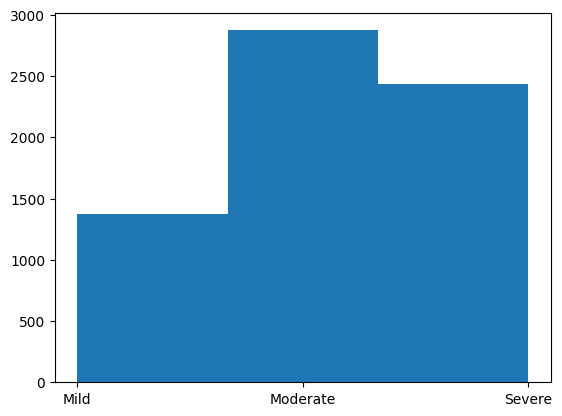

In [49]:
plt.hist(df['addiction_level'], bins=3)
plt.show()

histogram - what is the frequency of notifications per day? This didn't really show me anything

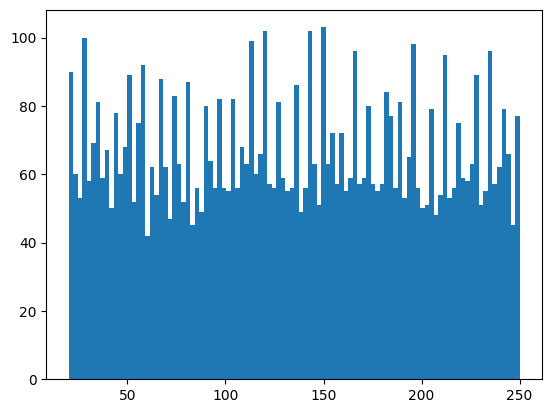

In [50]:
plt.hist(df['notifications_per_day'], bins=100)
plt.show()

Is there a direct correlation between how many notifications they get per day to how many times they open apps per day?
nope. doesn't look like it

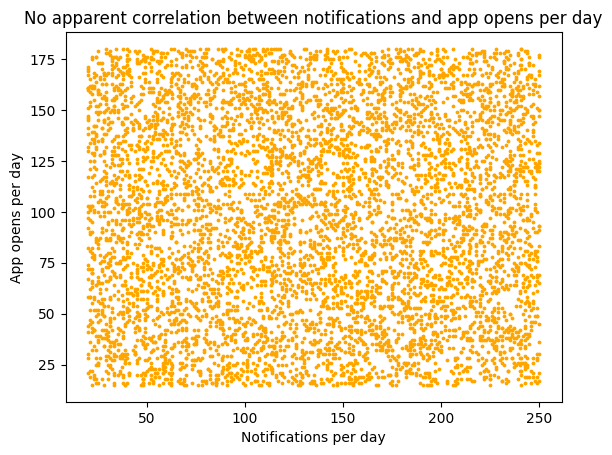

In [51]:
plt.scatter(
    df["notifications_per_day"], 
    df["app_opens_per_day"],
    color = "#FFA500",
    s = 3
    )

plt.xlabel('Notifications per day')
plt.ylabel('App opens per day')
plt.title('No apparent correlation between notifications and app opens per day')
plt.show()

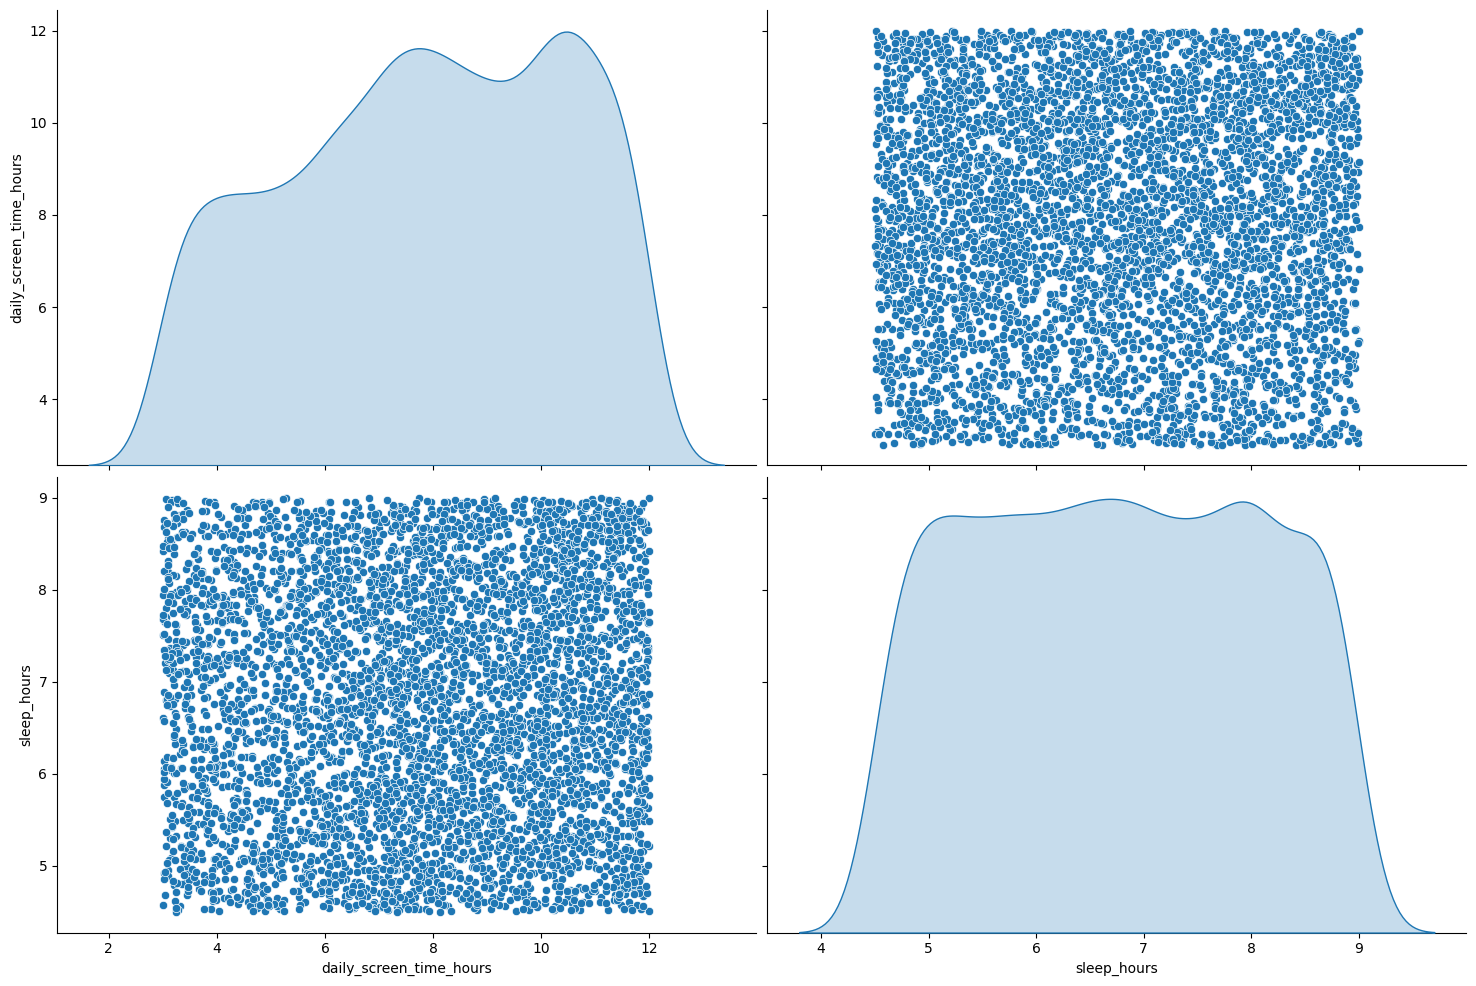

In [52]:
import seaborn
df_pairplot = df[['daily_screen_time_hours', 'sleep_hours']].sample(n=5000)
seaborn.pairplot(df_pairplot, height=5, aspect = 1.5, diag_kind='kde')

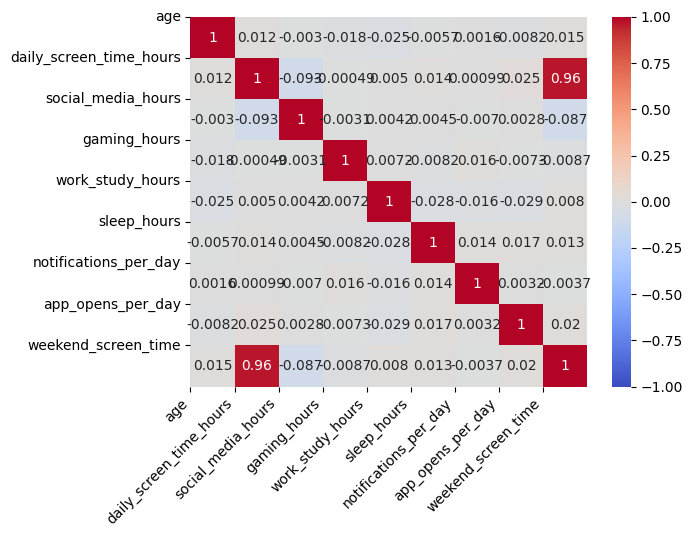

In [53]:
import numpy as np
numeric_smartphone = df.select_dtypes(include=[np.number])
corr = numeric_smartphone.corr()

seaborn.heatmap(corr, annot=True, vmin = -1, vmax = 1, cmap="coolwarm") #type, measurements, color
#plt.colorbar(label = "Pearson Corrrelation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha= "right")
plt.yticks(range(len(corr.columns)), corr.columns)


plt.show()

In [56]:
df[['app_opens_per_day', 'gaming_hours', 'notifications_per_day']].corr().round(4)


,app_opens_per_day,gaming_hours,notifications_per_day
app_opens_per_day,1.00,-0.01,0.00
gaming_hours,-0.01,1.00,0.02
notifications_per_day,0.00,0.02,1.00


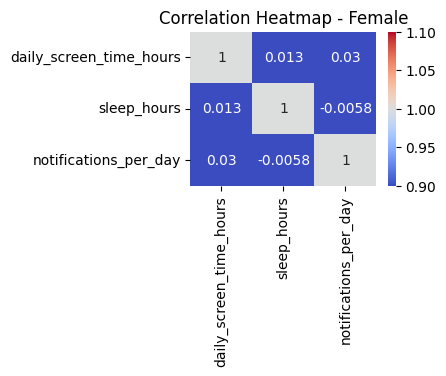

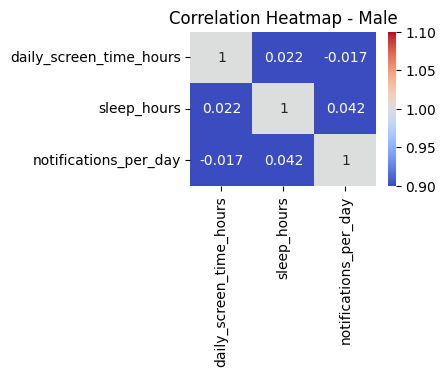

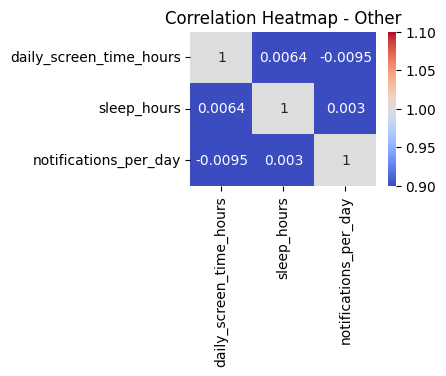

In [58]:
cols=['daily_screen_time_hours', 'sleep_hours', 'notifications_per_day']
for gender, group in df.groupby('gender'):
    corr = group[cols].corr()

    plt.figure(figsize = (3,2))
    seaborn.heatmap(corr, annot=True, cmap = 'coolwarm', vmin = 1, vmax = 1)
    plt.title(f'Correlation Heatmap - {gender}')
    plt.show()

In [61]:
df_stress = df.groupby('stress_level')['sleep_hours'].mean()
df_stress

stress_level
High     6.72
Low      6.76
Medium   6.75
Name: sleep_hours, dtype: float64

In [ ]:
#pie chart
ig, ax = plt.subplots(figsize=(8,8)) 

wedges, texts, autotexts = ax.pie( 
    platform_totals,
    autopct="%1.1f%%", 
    startangle=110, 
    colors=['gray', "#1b7b50" "#38d12a"] 
    )

ax.set_title( #title
    'Near Even Split Betweem Premium and Free Users',
    fontsize = 25,
    pad = 15,
    loc= "center"
)

for autotext in autotexts: #text inside wedges
    autotext.set_fontsize(30)
    autotext.set_color("white")
    autotext.set_weight("bold")


ax.legend(
    wedges, #legend for colors 
    platform_totals.index,
    loc= "lower center",
    bbox_to_anchor = (0.5, 0.92),
    ncol= 2
)
plt.show